In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dt = 0.01
noise_levels = np.logspace(-3, 0, 10).tolist()
t_spans = sorted([(0, 3*i) for i in range(1, 9 + 1)], reverse=True)

t_span_test = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': lambda x, t: dxdt_poly_fit(x, t, poly_deg=3, window_diameter=15),
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    'np_seed': 0, 'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_spans,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config, use_ESINDy=True, use_ridge=True, generate_prediction=False)

rows are noise_level. there are 10 rows.
columns are t_span_train. there are 9 columns.
step 1 of 10


100%|██████████| 9/9 [00:10<00:00,  1.14s/it]


step 2 of 10


100%|██████████| 9/9 [00:10<00:00,  1.18s/it]


step 3 of 10


...

100%|██████████| 9/9 [00:11<00:00,  1.33s/it]


step 9 of 10


100%|██████████| 9/9 [00:11<00:00,  1.25s/it]


step 10 of 10


100%|██████████| 9/9 [00:12<00:00,  1.41s/it]


rows are noise_level. there are 10 rows.
columns are t_span_train. there are 9 columns.


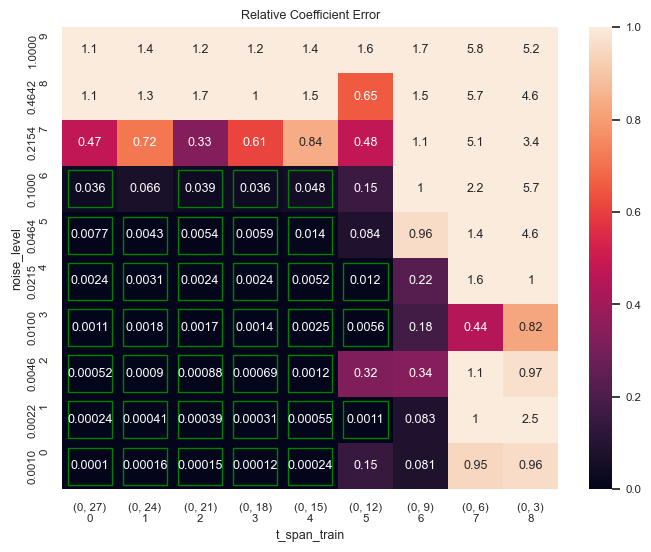

In [3]:
plot_heatmaps(experiment_config, results)

In [5]:
experiment_config2 = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    'np_seed': 0, 'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_spans,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results2 = run_experiment(experiment_config2, use_ESINDy=True, use_ridge=True, generate_prediction=False)

rows are noise_level. there are 10 rows.
columns are t_span_train. there are 9 columns.
step 1 of 10


100%|██████████| 9/9 [00:09<00:00,  1.08s/it]


step 2 of 10


100%|██████████| 9/9 [00:11<00:00,  1.28s/it]


step 3 of 10


...

100%|██████████| 9/9 [00:09<00:00,  1.09s/it]


step 9 of 10


100%|██████████| 9/9 [00:08<00:00,  1.08it/s]


step 10 of 10


100%|██████████| 9/9 [00:08<00:00,  1.11it/s]


rows are noise_level. there are 10 rows.
columns are t_span_train. there are 9 columns.


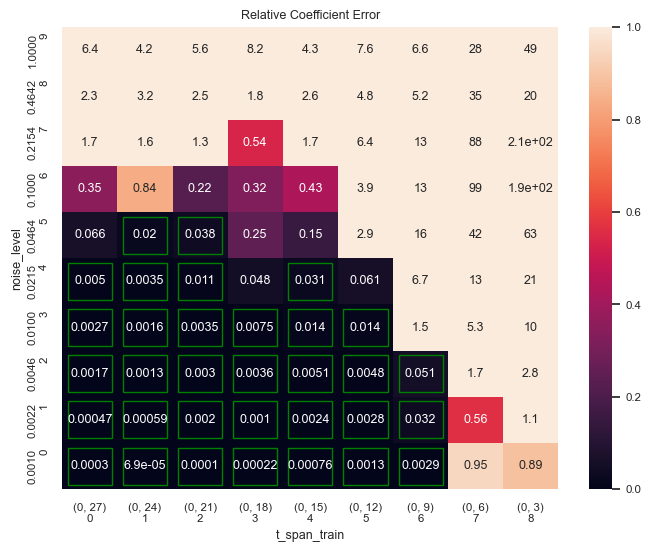

In [6]:
plot_heatmaps(experiment_config2, results2)